In [1]:
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
from uphate import get_phate_embedding
from phate.tree import gen_dla
from phate import PHATE

In [2]:
X, labels = gen_dla(n_branch=10)

In [ ]:
phate_op = PHATE(
    n_components=2,
    knn=5,
    t=20,
    n_landmark=None,
    mds_solver="smacof",
)

X_phate = phate_op.fit_transform(X)

Calculating PHATE...
  Running PHATE on 1000 observations and 100 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.01 seconds.
    Calculating affinities...
  Calculated graph and diffusion operator in 0.03 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.24 seconds.
    Calculating KMeans...
    Calculated KMeans in 0.69 seconds.
  Calculated landmark operator in 0.99 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.02 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 0.14 seconds.
Calculated PHATE in 1.24 seconds.


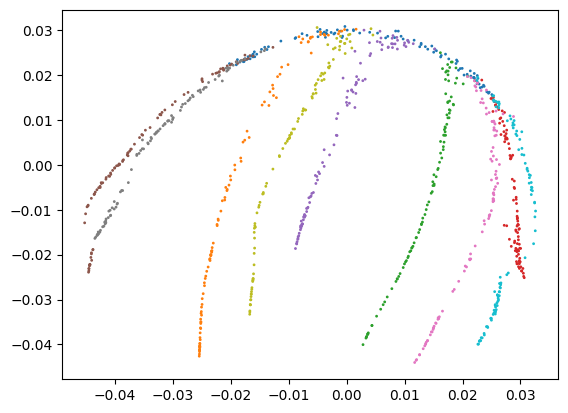

In [4]:
plt.scatter(*X_phate.T, c=labels, cmap="tab10", s=1)

In [5]:
X_uphate = get_phate_embedding(
    jnp.array(X),
    jax.random.key(20),
    n_components=2,
    knn=5,
    t=20,
    n_landmark=None,
).block_until_ready()

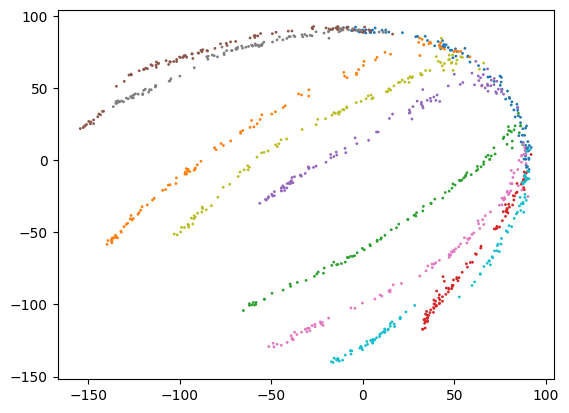

In [6]:
plt.scatter(*X_uphate.T, c=labels, cmap="tab10", s=1)

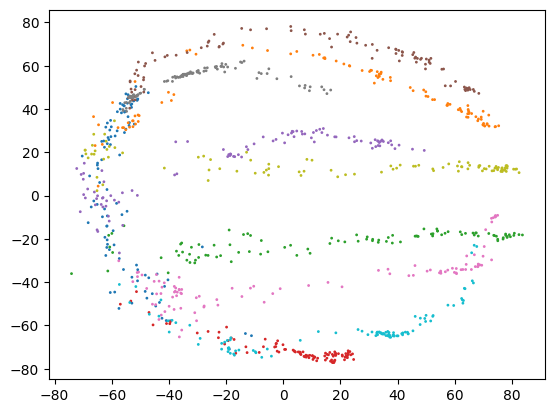

In [12]:
weights = jax.random.dirichlet(jax.random.key(20), jnp.ones(X.shape[0]) * 0.1)
X_uphate = get_phate_embedding(
    jnp.array(X),
    jax.random.key(20),
    n_components=2,
    knn=5,
    t=20,
    n_landmark=None,
    weights=weights,
)

plt.scatter(*X_uphate.T, c=labels, cmap="tab10", s=1)